In [1]:
import gillespy2
import numpy as np
import os
import sys
import time
import matplotlib.pyplot as plt
import jsf as jsf
from GillespieDirectMethod import gillespie_direct_method
%matplotlib widget


In [2]:

class BirthDeathModel_GP2(gillespy2.Model):
    def __init__(self, X0=10, Y0=10, X_growth_rate=1, X_death_rate=0.5, x_catalyst=1, y_death=1, t_max=5):
        super().__init__(name="BirthDeathModel")
        
        # Parameters
        self.add_parameter(gillespy2.Parameter(name="x_birth", expression=X_growth_rate ))
        self.add_parameter(gillespy2.Parameter(name="x_death", expression=X_death_rate))
        self.add_parameter(gillespy2.Parameter(name="y_death", expression=y_death))
        self.add_parameter(gillespy2.Parameter(name="x_catalyst", expression=x_catalyst))
        
        # Species
        # self.add_species(gillespy2.Species(name="X", initial_value=x0, switch_min=switch_th, switch_tol=0.1))
        self.add_species(gillespy2.Species(name="X", initial_value=X0 , mode="dynamic"))
        self.add_species(gillespy2.Species(name="Y", initial_value=Y0,  mode="dynamic"))
        
        # Reactions
        self.add_reaction(gillespy2.Reaction(name="birth", reactants={'X': 1}, products={'X': 2}, rate=self.listOfParameters['x_birth']))
        self.add_reaction(gillespy2.Reaction(name="death", reactants={'X': 1}, products={}, rate=self.listOfParameters['x_death']))
        self.add_reaction(gillespy2.Reaction(name="catalyst", reactants={'X': 1, 'Y': 1}, products={'X': 2, 'Y': 1}, propensity_function="x_catalyst*X*Y"))
        self.add_reaction(gillespy2.Reaction(name="death_Y", reactants={'Y': 1}, products={}, rate=self.listOfParameters['y_death']))
        
        self.timespan(np.linspace(0, t_max, round(1+t_max/0.001)))

def jsf_process(X0=10, Y0=10, X_growth_rate=1, X_death_rate=0.5, x_catalyst=1, y_death=1, t_max=5, switch_th=100):
    # Implement the JSF process
    # Define the Parameters

    # Define the stoichiometry
    reactant_matrix =[[1, 0],
                    [1, 0],
                    [1, 1],
                    [0, 1]]

    product_matrix = [[2, 0],
                    [0, 0],
                    [2, 1],
                    [0, 0]]

    # Define the rates
    rates = lambda x, t: [X_growth_rate  * x[0],
                        X_death_rate * x[0],
                        x_catalyst * x[0] * x[1],
                        y_death * x[1]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

    my_opts = {
                "EnforceDo": [0, 0],
                "dt": 0.001,
                "SwitchingThreshold": [switch_th, switch_th]
            }
    x0_v = [X0, Y0]

    sim_jsf = jsf.jsf(x0_v, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    return sim_jsf


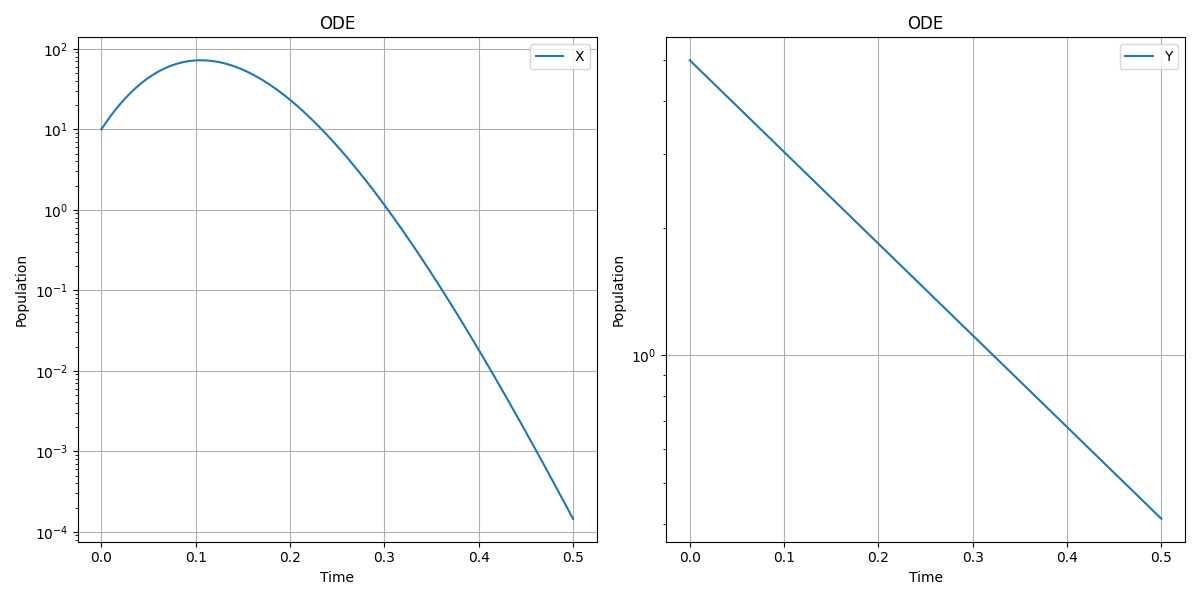

In [3]:
X0=10
Y0=5
X_growth_rate=1
X_death_rate=60
x_catalyst=20
y_death=5

t_max= 0.5
numb_of_traj= 1000


model = BirthDeathModel_GP2(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max)

# ODE
results_ode = model.run(algorithm="ODE")

# plot the ode results with each species in a different subplot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(results_ode[0]['time'], results_ode[0]['X'], label='X')
ax[1].plot(results_ode[0]['time'], results_ode[0]['Y'], label='Y')
for i in range(2):
    ax[i].set_title('ODE')
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Population')
    ax[i].legend()
    ax[i].grid()
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()



In [5]:
# Gillespy2
start_time = time.perf_counter()
results_gp2 = model.run(algorithm="Tau-Hybrid", number_of_trajectories=numb_of_traj)
end_time = time.perf_counter()
gp2_elapsed_time_total = end_time - start_time
gp2_elapsed_time_traj = gp2_elapsed_time_total / numb_of_traj
print(f"Elapsed time for Gillespy2: {gp2_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for Gillespy2: {gp2_elapsed_time_traj:0.4f} seconds")


Elapsed time for Gillespy2: 3781.4497 seconds
Elapsed time per trajectory for Gillespy2: 3.7814 seconds


In [ ]:

# JSF
# store the results
results_jsf = []

progress = 0
start_time = time.perf_counter()
for i in range(numb_of_traj):
    sim_jsf = jsf_process(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max, switch_th=100)
    results_jsf.append(sim_jsf)
    
    progress = (progress + 1)
    prog = round(progress / numb_of_traj * 100)
    print("|" + "-" * prog + " " * (100 - prog) + f"| {prog:.2f}%", end="\r") 
end_time = time.perf_counter()
jsf_elapsed_time_total = end_time - start_time
jsf_elapsed_time_traj = jsf_elapsed_time_total / numb_of_traj

print('\n')
print(f"Elapsed time for JSF: {jsf_elapsed_time_total:0.4f} seconds")
print(f"Elapsed time per trajectory for JSF: {jsf_elapsed_time_traj:0.4f} seconds")




|----------------------------------------------------------------------------------------------------| 100.00%

Elapsed time for JSF: 555.9993 seconds
Elapsed time per trajectory for JSF: 0.5560 seconds


In [11]:
def log_mean(data):
    data = np.array(data)
    # data[data == 0] = np.nan  # Replace zeros with NaN to avoid log(0)
    log_data = np.log(data)
    log_data[log_data == -np.inf] = 0  # Replace -inf with NaN
    mean_log = np.nanmean(log_data, axis=0)  # Compute mean ignoring NaNs
    return np.exp(mean_log)

# interpolate the results onto a common time grid
t_common = np.linspace(0, t_max, 501)
# store the results
results_jsf_interp = []
for sim_jsf in results_jsf:
    results_jsf_interp.append([np.interp(t_common, sim_jsf[1], sim_jsf[0][0]), np.interp(t_common, sim_jsf[1], sim_jsf[0][1])])

# mean_jsf = np.exp(np.mean(np.log(results_jsf_interp), axis=0))
# Calculate the log mean, accounting for zero values
# mean_jsf = log_mean(results_jsf_interp)
# mean_jsf = np.mean(results_jsf_interp, axis=0)
mean_jsf = np.median(results_jsf_interp, axis=0)

# # do the same for gp2
results_gp2_interp = []
for traj in results_gp2:
    results_gp2_interp.append([np.interp(t_common, traj['time'], traj['X']), np.interp(t_common, traj['time'], traj['Y'])])

# compute the mean using the interpolated results
# mean_gp2 = np.exp(np.mean(np.log(results_gp2_interp), axis=0))
# mean_gp2 = log_mean(results_gp2_interp)
# mean_gp2 = np.mean(results_gp2_interp, axis=0)
mean_gp2 = np.median(results_gp2_interp, axis=0)



<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\O'
<>:65: SyntaxWarning: invalid escape sequence '\O'
<>:73: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/3911380909.py:65: SyntaxWarning: invalid escape sequence '\O'
  ax[1, 0].set_title('JSF: $\Omega = 10^2$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/3911380909.py:73: SyntaxWarning: invalid escape sequence '\O'
  ax[1, 1].set_title('JSF: $\Omega = 10^2$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/3911380909.py:8: RuntimeWarning: divide by zero encountered in log
  max_values_gp2 = [np.max(np.log(traj[0])) for traj in results_gp2_interp]
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/3911380909.py:9: RuntimeWarning: divide by zero encountered in log
  max_values_jsf = [np.max(np.log(traj[0])) for traj in results_jsf_interp]


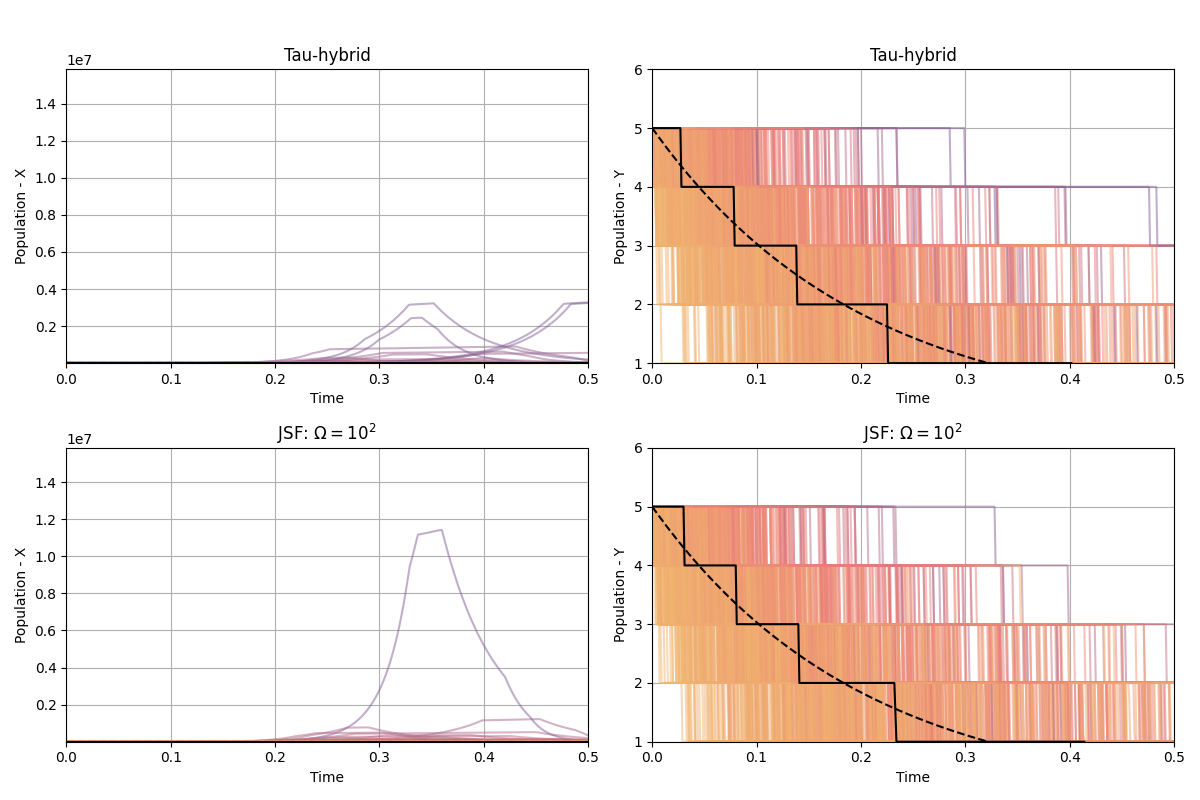

In [74]:
from matplotlib.colors import LinearSegmentedColormap

alpha_val = 0.5

# Determine the color based on the maximum value of each trajectory
# max_values_gp2 = [max(np.log(traj[0])) for traj in results_gp2_interp]
# max_values_jsf = [max(np.log(traj[0])) for traj in results_jsf_interp]
max_values_gp2 = [np.max(np.log(traj[0])) for traj in results_gp2_interp]
max_values_jsf = [np.max(np.log(traj[0])) for traj in results_jsf_interp]

# Normalize the maximum values to the range [0, 1] for color mapping
norm_gp2 = plt.Normalize(min(max_values_gp2), max(max_values_gp2))
norm_jsf = plt.Normalize(min(max_values_jsf), max(max_values_jsf))

# Create a color map
# Define the color gradient
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)
colors = [gil_color, gp2_color, jsf_color]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# plot the results
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for idx, traj in enumerate(results_gp2_interp):
    color_gp2 = cmap(norm_gp2(max_values_gp2[idx]))
    ax[0, 0].plot(t_common, traj[0], color=color_gp2, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
    ax[0, 1].plot(t_common, traj[1], color=color_gp2, label=f'Gillespy2 {idx+1}', alpha=alpha_val)
ax[0, 0].plot(t_common, mean_gp2[0], 'k-', label='Mean')
ax[0, 1].plot(t_common, mean_gp2[1], 'k-', label='Mean')

ax[0, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[0, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')



for idx, sim_jsf in enumerate(results_jsf_interp):
    color_jsf = cmap(norm_jsf(max_values_jsf[idx]))
    ax[1, 0].plot(t_common, sim_jsf[0], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)
    ax[1, 1].plot(t_common, sim_jsf[1], color=color_jsf, label=f'JSF {idx+1}', alpha=alpha_val)

ax[1, 0].plot(t_common, mean_jsf[0], 'k-', label='Mean')
ax[1, 1].plot(t_common, mean_jsf[1], 'k-', label='Mean')

ax[1, 0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1, 1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0, 0].set_title('Tau-hybrid')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Population - X')
# ax[0, 0].set_yscale('log')
ax[0, 0].set_ylim(1, 10**7.2)
ax[0, 0].set_xlim(0, 0.5)
ax[0, 0].grid()

ax[0, 1].set_title('Tau-hybrid')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Population - Y')
# ax[0, 1].set_yscale('log')
ax[0, 1].set_ylim(1, 6)
ax[0, 1].set_xlim(0, 0.5)
ax[0, 1].grid()

ax[1, 0].set_title('JSF: $\Omega = 10^2$')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Population - X')
# ax[1, 0].set_yscale('log')
ax[1, 0].set_ylim(1, 10**7.2)
ax[1, 0].set_xlim(0, 0.5)
ax[1, 0].grid()

ax[1, 1].set_title('JSF: $\Omega = 10^2$')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Population - Y')
# ax[1, 1].set_yscale('log')
ax[1, 1].set_ylim(1, 6)
ax[1, 1].set_xlim(0, 0.5)
ax[1, 1].grid()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.savefig('AutocatalystTrajectores.pdf')

IndexError: tuple index out of range

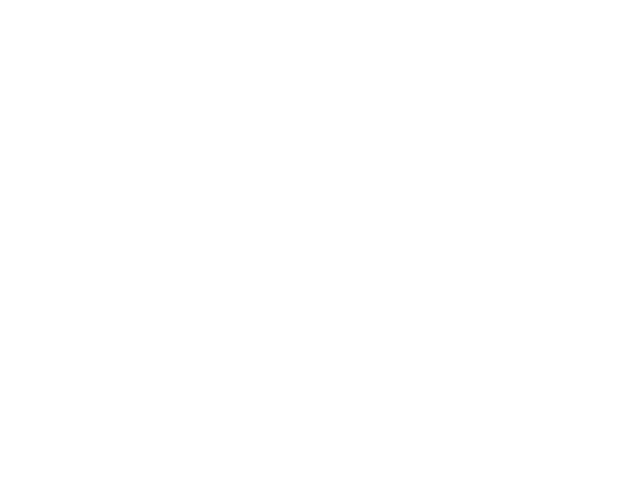

In [89]:
ind_sim_jsf = jsf_process(X0, Y0, X_growth_rate, X_death_rate, x_catalyst, y_death, t_max=t_max, switch_th=100)

plt.figure()
Ind = ind_sim_jsf[2]  # Example indicator function
plt.plot(ind_sim_jsf[1][Ind == 1], ind_sim_jsf[0][0][Ind == 1], 'ro-', label='X (Ind=1)')
plt.plot(ind_sim_jsf[1][Ind == 0], ind_sim_jsf[0][0][Ind == 0], 'bo-', label='X (Ind=0)')
# plt.plot(results_jsf, results_jsf[i][1], label='Y')
# plt.yscale('log')
plt.legend()
plt.grid()
plt.show()




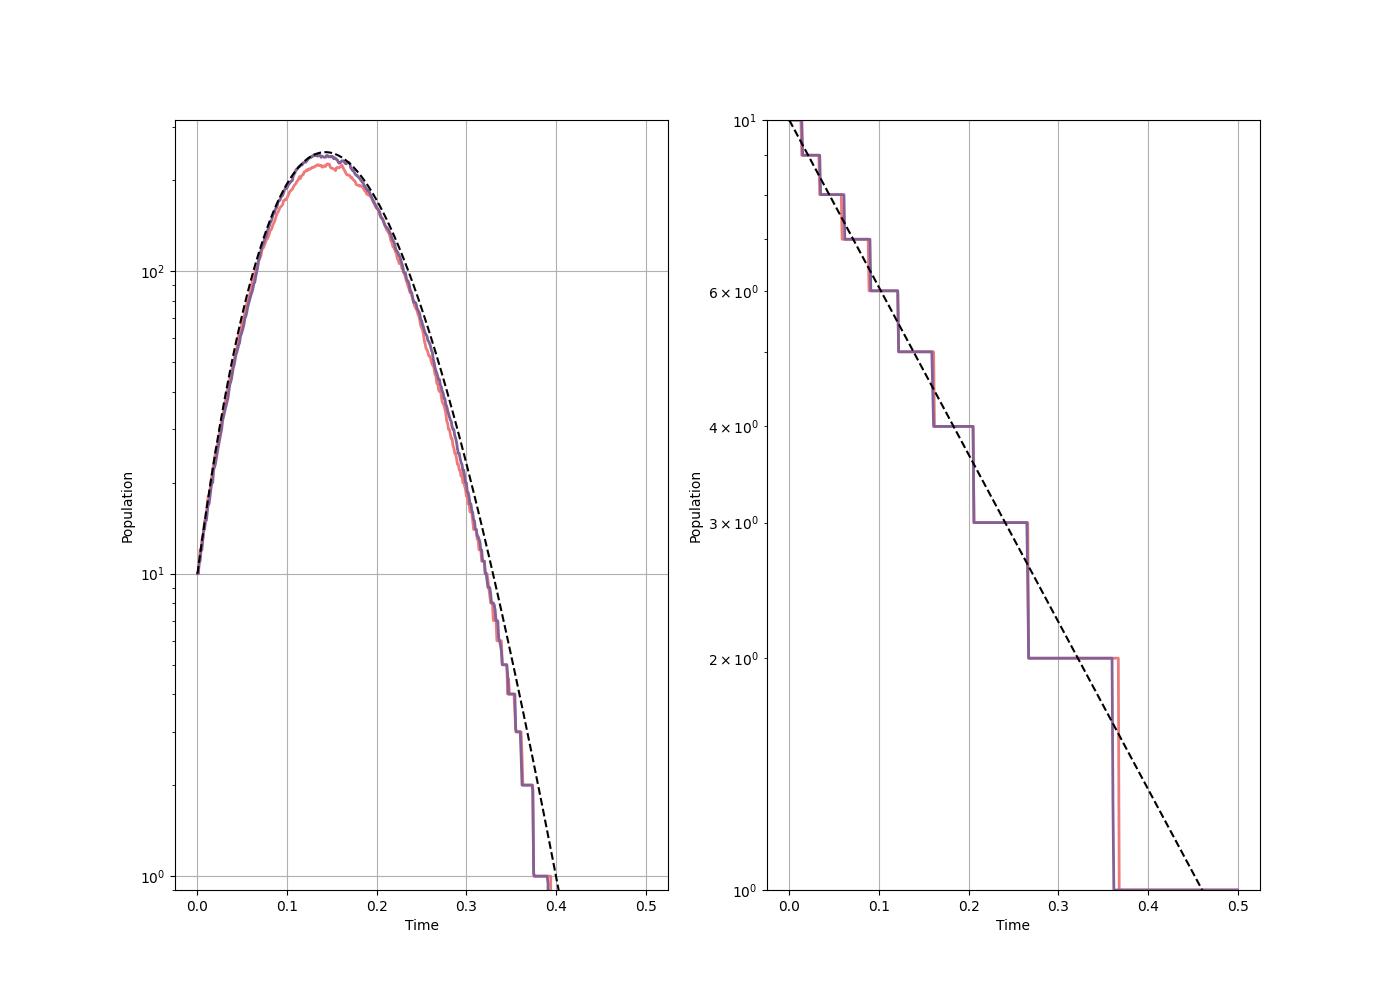

In [25]:
from matplotlib.colors import LinearSegmentedColormap

alpha_val = 0.25

# Create a color map
# Define the color gradient
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)

# plot the results
fig, ax = plt.subplots(1, 2, figsize=(14, 10))


ax[0].plot(t_common, mean_gp2[0], '-', label='Mean', color=gp2_color, linewidth=2)
ax[1].plot(t_common, mean_gp2[1], '-', label='Mean', color=gp2_color, linewidth=2)

ax[0].plot(t_common, mean_jsf[0], '-', label='Mean', color=jsf_color, linewidth=2)
ax[1].plot(t_common, mean_jsf[1], '-', label='Mean', color=jsf_color, linewidth=2)

ax[0].plot(results_ode['time'], results_ode['X'], 'k--', label='Analytic')
ax[1].plot(results_ode['time'], results_ode['Y'], 'k--', label='Analytic')

ax[0].set_xlabel('Time')
ax[0].set_ylabel('Population')
ax[0].set_yscale('log')
ax[0].set_ylim(0.9, pow(10,2.5))
ax[0].grid()

ax[1].set_xlabel('Time')
ax[1].set_ylabel('Population')
ax[1].set_yscale('log')
ax[1].set_ylim(1, 10)
ax[1].grid()

plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
<>:34: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:74: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:34: SyntaxWarning: invalid escape sequence '\O'
  ax[0].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:35: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Maximum X Population - $\log_{10}(X)$')
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_55090/2749522603.py:62: SyntaxWarning: invalid escape sequence '\O'
  ax[1].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
/var/folders/w6/dtzmmv8

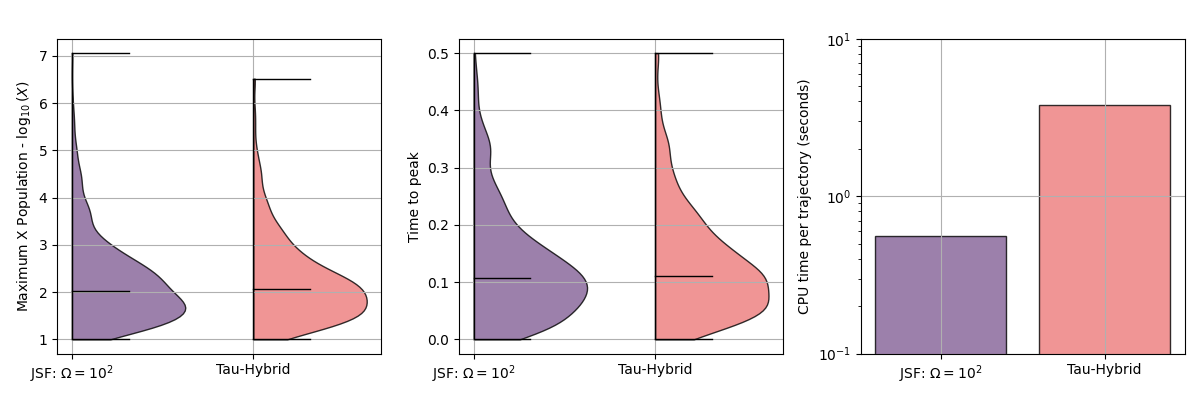

In [72]:
alpha_val = 0.8

max_values_gp2 = np.log10([np.max((traj[0])) for traj in results_gp2_interp])
max_values_jsf = np.log10([np.max((traj[0])) for traj in results_jsf_interp])

# compute the time to the peak value
peak_time_gp2 = [t_common[np.argmax(traj[0])] for traj in results_gp2_interp]
peak_time_jsf = [t_common[np.argmax(traj[0])] for traj in results_jsf_interp]

# determine the distribution of the maximum values
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

data = [max_values_jsf, max_values_gp2]
positions = [1, 2]
colors = [jsf_color, gp2_color]

violin_parts = ax[0].violinplot(data, positions=positions, showextrema=True, showmedians=True, side='high', widths=1.25)

# Set the colors for the violins
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor(colors[i])
    pc.set_alpha(alpha_val)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Customize the other parts of the violin plot
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    vp = violin_parts[partname]
    vp.set_edgecolor('black')
    vp.set_linewidth(1)

ax[0].set_xticks(positions)
ax[0].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[0].set_ylabel('Maximum X Population - $\log_{10}(X)$')
ax[0].grid()


# Combine the two histograms onto one plot
# Combine the two distributions into violin plots
data = [peak_time_jsf, peak_time_gp2]
positions = [1, 2]
colors = [jsf_color, gp2_color]

violin_parts = ax[1].violinplot(data, positions=positions, showextrema=True, showmedians=True, side='high', widths=1.25)

# Set the colors for the violins
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor(colors[i])
    pc.set_alpha(alpha_val)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Customize the other parts of the violin plot
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    vp = violin_parts[partname]
    vp.set_edgecolor('black')
    vp.set_linewidth(1)

ax[1].set_xticks(positions)
ax[1].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[1].set_ylabel('Time to peak')
ax[1].grid()

# create a bar chart for the simulation time required
data = [jsf_elapsed_time_total, gp2_elapsed_time_total]
data = [jsf_elapsed_time_traj, gp2_elapsed_time_traj]
positions = [1, 2]
colors = [jsf_color, gp2_color]

ax[2].bar(positions, data, color=colors, alpha=alpha_val, edgecolor='black', linewidth=1)
ax[2].set_xticks(positions)
ax[2].set_xticklabels(['JSF: $\Omega = 10^2$', 'Tau-Hybrid'])
ax[2].set_ylabel('CPU time per trajectory (seconds)')
ax[2].grid()
ax[2].set_yscale('log')
ax[2].set_ylim(pow(10,-1), pow(10,1))

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()



# save the figure
plt.savefig('AutocatalystSummaryData.pdf')

In [60]:
[jsf_elapsed_time_traj, gp2_elapsed_time_traj]
gp2_elapsed_time_traj/jsf_elapsed_time_traj

6.801177227095451